# Notebook 01: Data Audit and Exploratory Data Analysis (EDA)

This notebook performs the initial data quality audit, descriptive statistics, and exploratory data analysis.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data
We only load the 3 selected stations: Aotizhongxin, Changping, and Dingling.

In [15]:
raw_dir = '../data/raw/PRSA_Data_20130301-20170228'
# If the directory is different due to extraction, we can also search recursively:
files = glob.glob('../data/raw/**/*.csv', recursive=True)
target_stations = ['Aotizhongxin', 'Changping', 'Dingling']

dfs = []
for f in files:
    if any(station in f for station in target_stations):
        df = pd.read_csv(f)
        dfs.append(df)

df_raw = pd.concat(dfs, ignore_index=True)
print(f"Loaded {len(df_raw)} rows from {len(dfs)} stations.")
df_raw.head()

Loaded 105192 rows from 3 stations.


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


## 2. Data Quality Audit

In [16]:
# Missing values per column
missing_audit = df_raw.isnull().sum().to_frame(name='Missing Count')
missing_audit['Missing Percentage (%)'] = (missing_audit['Missing Count'] / len(df_raw)) * 100
print("Missing Values Audit:")
display(missing_audit)

# Duplicate rows
dupes = df_raw.duplicated().sum()
print(f"\nNumber of duplicate rows: {dupes}")

Missing Values Audit:


,Missing Count,Missing Percentage (%)
No,0,0.000000
year,0,0.000000
month,0,0.000000
day,0,0.000000
hour,0,0.000000
PM2.5,2478,2.355692
PM10,1956,1.859457
SO2,2293,2.179824
NO2,2924,2.779679
CO,5309,5.046962



Number of duplicate rows: 0


## 3. Descriptive Statistics

In [17]:
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.drop(['No', 'year', 'month', 'day', 'hour'])
desc_stats = df_raw[numeric_cols].describe()
display(desc_stats)

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,102714.000000,103236.000000,102899.000000,102268.000000,99883.000000,101655.000000,105066.000000,105072.000000,105066.000000,105070.000000,105092.000000
mean,73.274027,96.143238,14.689739,43.726067,1107.307420,60.952020,13.652255,1009.123270,2.045023,0.062719,1.805363
std,76.033342,86.990012,20.141019,33.896091,1094.581622,55.606775,11.376585,10.464315,13.798774,0.808716,1.277345
min,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-16.800000,982.400000,-35.300000,0.000000,0.000000
25%,17.000000,32.000000,2.000000,18.000000,400.000000,17.000000,3.300000,1000.600000,-9.600000,0.000000,1.000000
50%,48.000000,72.000000,7.000000,35.000000,800.000000,51.000000,14.600000,1008.700000,2.500000,0.000000,1.500000
75%,103.000000,135.000000,18.000000,63.000000,1400.000000,85.000000,23.300000,1017.400000,14.700000,0.000000,2.300000
max,898.000000,999.000000,341.000000,290.000000,10000.000000,500.000000,41.400000,1042.000000,28.500000,72.500000,11.200000


## 4. Seasonal Trends of PM2.5
To answer our questions about winter inversions, we must see how PM2.5 fluctuates over the year.

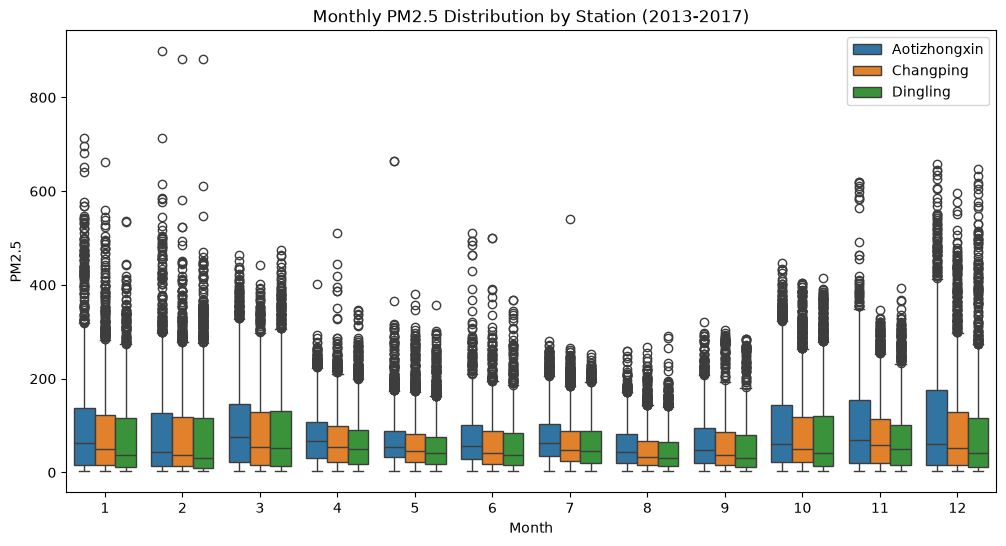

In [18]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='month', y='PM2.5', hue='station', data=df_raw)
plt.title('Monthly PM2.5 Distribution by Station (2013-2017)')
plt.ylabel('PM2.5')
plt.xlabel('Month')
plt.legend(loc='upper right')
plt.savefig('../figures/monthly_pm25_boxplot.png')
plt.show()

## 5. Correlations among Co-pollutants
This supports the need for PCA later.

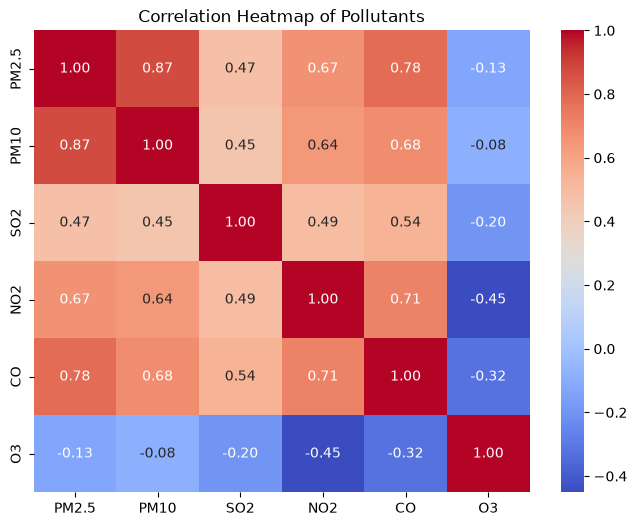

In [19]:
pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
corr_matrix = df_raw[pollutants].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Pollutants')
plt.savefig('../figures/pollutant_correlation.png')
plt.show()